**Name: Mst. Shikha Khatun**

**ID: 2511932**

**Course Code: CSC525**

**Group: 2**

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


# **Call Library**

In [ ]:
# Basic Libraries
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pandas as pd

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model

# Evaluation
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix
from sklearn.utils import class_weight

# **Load dataset**
CSV files are used to obtain image IDs and labels, which are then used to create image paths. Images are read, normalized, and resized to 224 x 224.

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/CSC525_Project/Dataset/RFMiD_Training_Labels.csv")
image_paths = "/content/drive/MyDrive/CSC525_Project/Dataset/Training_Set/Training/" + df["ID"].astype(str) + ".png"

val_df= pd.read_csv("/content/drive/MyDrive/CSC525_Project/Dataset/RFMiD_Validation_Labels.csv")
val_paths = "/content/drive/MyDrive/CSC525_Project/Dataset/Validation/" + val_df["ID"].astype(str) + ".png"


test_df = pd.read_csv("/content/drive/MyDrive/CSC525_Project/Dataset/RFMiD_Testing_Labels.csv")
test_paths = "/content/drive/MyDrive/CSC525_Project/Dataset/Test/" + test_df["ID"].astype(str) + ".png"

labels = df["Disease_Risk"].to_numpy()
val_labels = val_df["Disease_Risk"].to_numpy()
test_labels = test_df["Disease_Risk"].to_numpy()

data = tf.data.Dataset.from_tensor_slices((image_paths, labels))
val = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
test = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))

def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, (224, 224))
    image = image/255.0
    return image, label

data = data.map(load_image).shuffle(1000).batch(32).prefetch(tf.data.AUTOTUNE)
val = val.map(load_image).batch(32).prefetch(tf.data.AUTOTUNE)
test = test.map(load_image).batch(32).prefetch(tf.data.AUTOTUNE)

In [ ]:
drive_path = '/content/drive/MyDrive'
print(f"Listing contents of: {drive_path}")

for root, dirs, files in os.walk(drive_path):
    level = root.replace(drive_path, '').count(os.sep)
    indent = ' ' * 4 * (level)
    #print(f'{indent}{os.path.basename(root)}/')

Listing contents of: /content/drive/MyDrive


In [ ]:
print("Train:\n", df["Disease_Risk"].value_counts())
print("Val:\n", val_df["Disease_Risk"].value_counts())
print("Test:\n", test_df["Disease_Risk"].value_counts())

Train:
 Disease_Risk
1    1519
0     401
Name: count, dtype: int64
Val:
 Disease_Risk
1    506
0    134
Name: count, dtype: int64
Test:
 Disease_Risk
1    506
0    134
Name: count, dtype: int64


# **Visualization**

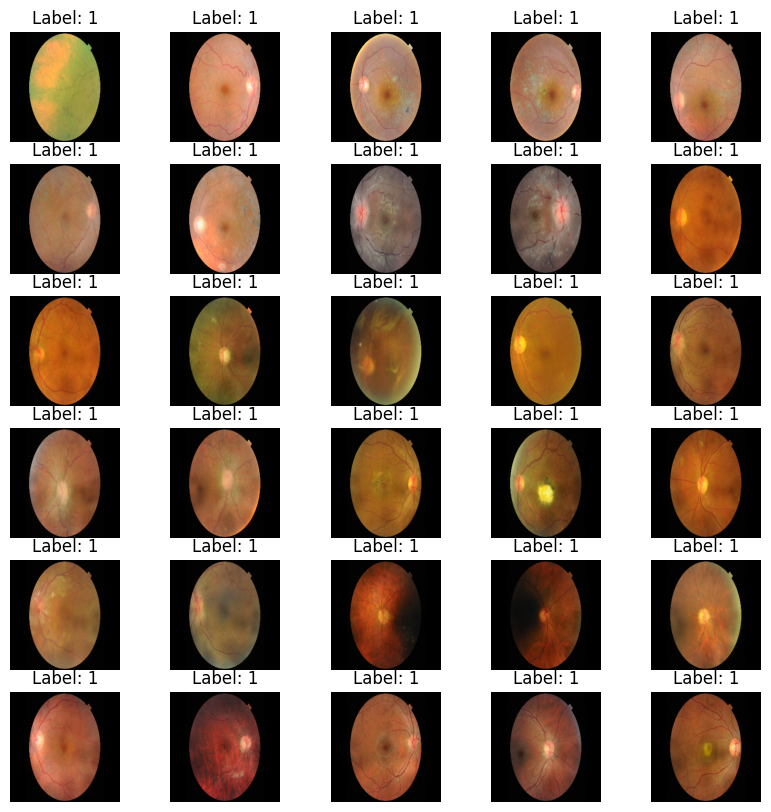

In [ ]:
img, label = next(iter(val))

plt.figure(figsize=(10,10))

for i in range(30):
    # Adjusted subplot to 5 rows and 4 columns to accommodate 20 images
    plt.subplot(6, 5, i + 1)
    plt.imshow((img[i].numpy()*255).astype("uint8"))
    plt.title(f"Label: {label[i].numpy()}") # Removed [0] as label[i].numpy() is already a scalar
    plt.axis("off")

plt.show()

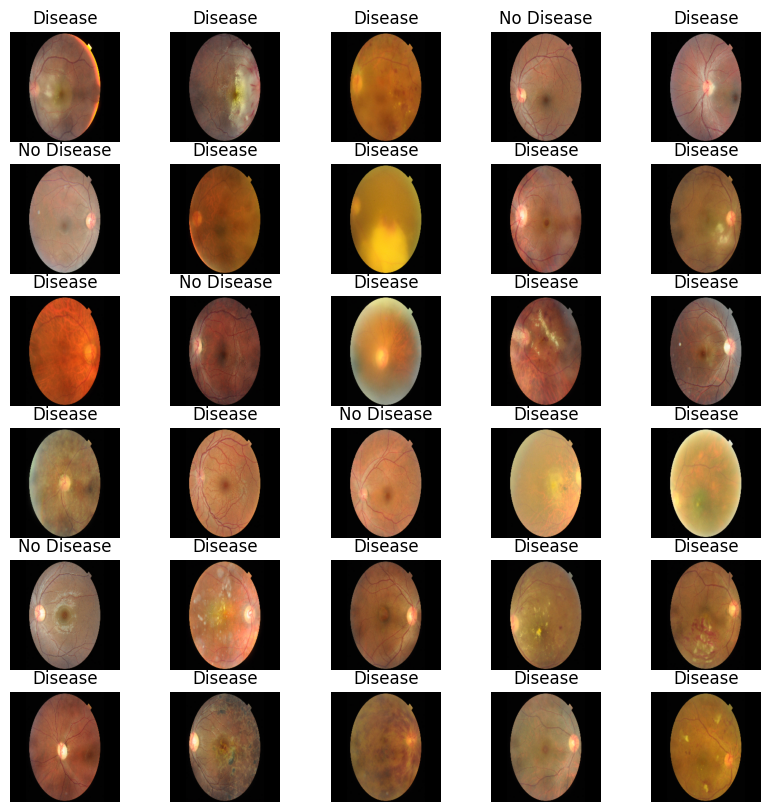

In [ ]:
images, labels = next(iter(data))

plt.figure(figsize=(10,10))

for i in range(30):
    plt.subplot(6, 5, i + 1)
    plt.imshow((images[i].numpy()*255).astype("uint8"))

    label = labels[i].numpy()
    text = "No Disease" if label == 0 else "Disease"

    plt.title(text)
    plt.axis("off")
plt.show()

**Load Pretrained ResNet50**

In [ ]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dense(128, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

**ModelCheckpoint callback used to save the best-performing model. Training stops early to prevent overfitting.**



In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor='val_accuracy',
    save_best_only=True
)

# **Class Imbalance**
To address class imbalance, class weights are computed using the training labels. During training, these weights assist the model in giving less frequent classes more weight.

In [ ]:
from sklearn.utils import class_weight
import numpy as np
y_labels = labels.numpy()

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_labels),
    y=y_labels
)

class_weights = dict(enumerate(class_weights))

**Model trained using the training dataset. Training conducted for a maximum of 15 epochs.**

In [ ]:
history = model.fit(
    data,
    validation_data=val,
    epochs=15,
    callbacks=[early_stop, checkpoint],
    class_weight=class_weights
)

Epoch 1/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.4541 - loss: 0.7631 - precision: 0.8099 - recall: 0.4362 

60/60 ━━━━━━━━━━━━━━━━━━━━ 1070s 17s/step - accuracy: 0.3969 - loss: 0.7726 - precision: 0.8229 - recall: 0.3028 - val_accuracy: 0.2094 - val_loss: 0.8292 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 662s 10s/step - accuracy: 0.4396 - loss: 0.7511 - precision: 0.8510 - recall: 0.3535 - val_accuracy: 0.2094 - val_loss: 0.8786 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.3568 - loss: 0.7314 - precision: 0.8160 - recall: 0.2751

60/60 ━━━━━━━━━━━━━━━━━━━━ 684s 10s/step - accuracy: 0.3635 - loss: 0.7605 - precision: 0.8140 - recall: 0.2535 - val_accuracy: 0.2219 - val_loss: 0.8623 - val_precision: 1.0000 - val_recall: 0.0158
Epoch 4/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.3806 - loss: 0.7204 - precision: 0.9159 - recall: 0.2734

60/60 ━━━━━━━━━━━━━━━━━━━━ 704s 11s/step - accuracy: 0.3615 - loss: 0.7501 - precision: 0.9014 - recall: 0.2166 - val_accuracy: 0.2234 - val_loss: 0.9056 - val_precision: 1.0000 - val_recall: 0.0178
Epoch 5/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.4886 - loss: 0.6941 - precision: 0.9006 - recall: 0.4416

60/60 ━━━━━━━━━━━━━━━━━━━━ 699s 11s/step - accuracy: 0.4500 - loss: 0.7448 - precision: 0.8826 - recall: 0.3515 - val_accuracy: 0.2266 - val_loss: 0.9094 - val_precision: 1.0000 - val_recall: 0.0217
Epoch 6/15
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.3481 - loss: 0.7184 - precision: 0.9072 - recall: 0.2329

60/60 ━━━━━━━━━━━━━━━━━━━━ 664s 10s/step - accuracy: 0.3630 - loss: 0.7455 - precision: 0.8957 - recall: 0.2205 - val_accuracy: 0.2391 - val_loss: 0.8931 - val_precision: 1.0000 - val_recall: 0.0375


**Accuracy and loss curves plotting**

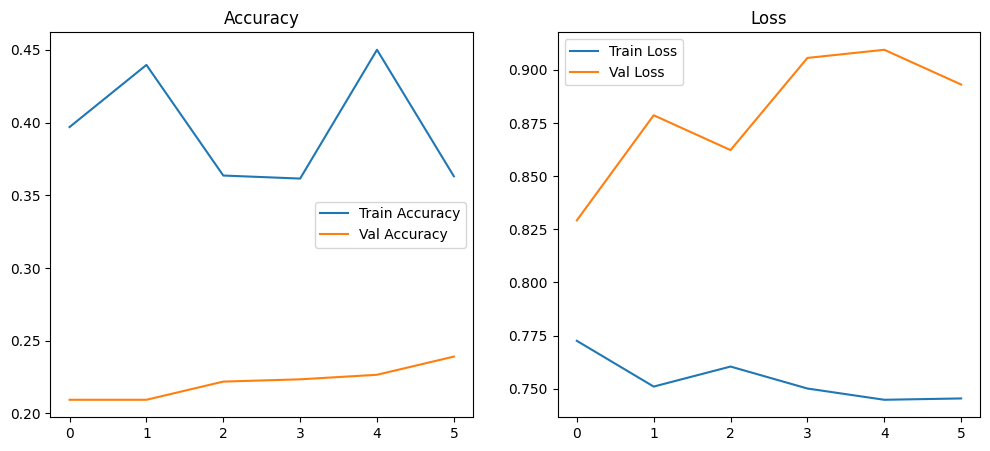

In [ ]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy")

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")

plt.show()

In [ ]:
test_loss, test_acc, test_precision, test_recall = model.evaluate(test)

print("Test Accuracy:", test_acc)
print("Test Precision:", test_precision)
print("Test Recall:", test_recall)

20/20 ━━━━━━━━━━━━━━━━━━━━ 214s 10s/step - accuracy: 0.2094 - loss: 0.8302 - precision: 0.0000e+00 - recall: 0.0000e+00
Test Accuracy: 0.20937499403953552
Test Precision: 0.0
Test Recall: 0.0


In [ ]:
y_true = []
y_pred = []

for images, labels in test:
    preds = model.predict(images)
    preds = (preds > 0.5).astype(int).flatten()

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


**Confusion Matrix created**

[[134   0]
 [506   0]]


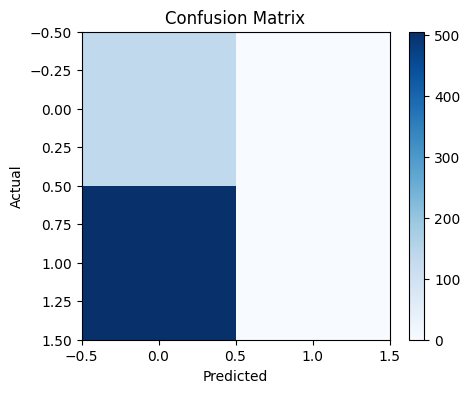

In [ ]:
cm = confusion_matrix(y_true, y_pred)

print(cm)

plt.figure(figsize=(5,4))
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

In [ ]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.21      1.00      0.35       134
           1       0.00      0.00      0.00       506

    accuracy                           0.21       640
   macro avg       0.10      0.50      0.17       640
weighted avg       0.04      0.21      0.07       640



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**ROC Curve Created**

AUC Score: 0.8032564450474898


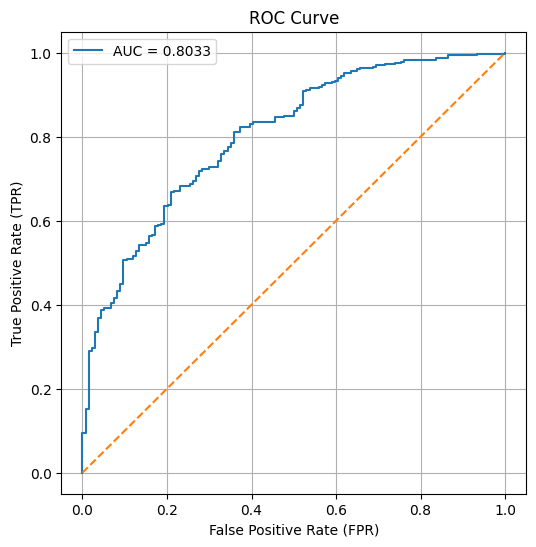

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_true = []
y_scores = []

for images, labels in test:
    preds = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_scores.extend(preds.flatten())
y_true = np.array(y_true)
y_scores = np.array(y_scores)

fpr, tpr, thresholds = roc_curve(y_true, y_scores)

roc_auc = auc(fpr, tpr)

print("AUC Score:", roc_auc)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve")
plt.legend()
plt.grid()

plt.show()